# wind power Generation forecasting

In [2]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

In [8]:
location1 = pd.read_csv('location1.csv')
location2 = pd.read_csv('location2.csv')
location3 = pd.read_csv('location3.csv')
location4 = pd.read_csv('location4.csv')

In [9]:
location1.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793


In [10]:
location2.head(58)

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,14.5,91,12.4,6.37,9.58,68,72,9.9,0.2574
1,2017-01-02 01:00:00,14.5,92,12.7,6.46,9.23,68,72,9.5,0.2535
2,2017-01-02 02:00:00,14.7,92,12.7,6.18,9.27,67,74,9.4,0.2497
3,2017-01-02 03:00:00,14.7,92,12.8,5.91,9.08,62,69,9.1,0.2458
4,2017-01-02 04:00:00,14.8,92,12.9,5.88,8.72,58,65,8.7,0.2419
5,2017-01-02 05:00:00,14.7,92,12.9,6.12,8.83,52,59,8.8,0.2354
6,2017-01-02 06:00:00,14.4,92,12.5,6.37,8.98,48,52,9.1,0.2261
7,2017-01-02 07:00:00,14.2,92,12.3,6.33,9.24,51,56,9.3,0.2168
8,2017-01-02 08:00:00,14.1,92,12.2,5.97,9.10,50,57,9.2,0.2075
9,2017-01-02 09:00:00,14.2,92,12.2,5.74,8.77,49,55,8.8,0.1982


In [11]:
#Add a new column
location1['Location']='Location1'
location2['Location']='Location2'
location3['Location']='Location3'
location4['Location']='Location4'

# concatinate the data frame
merged_data = pd.concat([location1,location2,location3,location4],ignore_index=True)
merged_data.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,Location1
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,Location1
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,Location1
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,Location1
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,Location1


In [12]:
#save the merged data set to new csv file
merged_data.to_csv('merged_locations.csv' , index = False)

In [13]:
# To show the merged data info
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175200 entries, 0 to 175199
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Time                 175200 non-null  object 
 1   temperature_2m       175200 non-null  float64
 2   relativehumidity_2m  175200 non-null  int64  
 3   dewpoint_2m          175200 non-null  float64
 4   windspeed_10m        175200 non-null  float64
 5   windspeed_100m       175200 non-null  float64
 6   winddirection_10m    175200 non-null  int64  
 7   winddirection_100m   175200 non-null  int64  
 8   windgusts_10m        175200 non-null  float64
 9   Power                175200 non-null  float64
 10  Location             175200 non-null  object 
dtypes: float64(6), int64(3), object(2)
memory usage: 14.7+ MB


In [14]:
# To check the statistics of Dataset
merged_data.describe()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
count,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000
mean,46.655994,70.155291,36.516241,4.157639,6.879334,201.589446,201.539070,8.038205,0.303429
std,22.012738,17.326678,20.933153,2.012682,3.043964,99.639040,100.683777,3.617488,0.257325
min,-31.200000,9.000000,-36.200000,0.000000,0.000000,1.000000,0.000000,0.500000,0.000000
25%,30.200000,57.000000,21.900000,2.630000,4.700000,130.000000,129.000000,5.300000,0.087700
50%,46.900000,72.000000,36.200000,3.850000,6.680000,211.000000,211.000000,7.600000,0.233100
75%,65.300000,84.000000,54.600000,5.380000,8.800000,288.000000,290.000000,10.300000,0.474200
max,101.700000,100.000000,78.700000,18.530000,24.590000,360.000000,360.000000,29.200000,0.999400


In [15]:
# Check the missing value
merged_data.isnull().sum()

Time                   0
temperature_2m         0
relativehumidity_2m    0
dewpoint_2m            0
windspeed_10m          0
windspeed_100m         0
winddirection_10m      0
winddirection_100m     0
windgusts_10m          0
Power                  0
Location               0
dtype: int64

In [16]:
# To check the duplicate values
merged_data.duplicated().sum()

np.int64(0)

In [17]:
# To encode the values or to assign some values and encode catagorical values
merged_data = pd.get_dummies(merged_data,columns=['Location'],drop_first=True)
merged_data.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False


In [18]:
merged_data.columns


Index(['Time', 'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
       'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
       'winddirection_100m', 'windgusts_10m', 'Power', 'Location_Location2',
       'Location_Location3', 'Location_Location4'],
      dtype='object')

In [19]:
# Let's  remove the time column
merged_data.drop('Time', axis=1, inplace=True)
merged_data.head()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
0,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False
1,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False
2,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False
3,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False
4,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False


In [20]:
merged_data.fillna(merged_data.median(), inplace=True)
merged_data.head()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
0,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False
1,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False
2,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False
3,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False
4,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False


In [21]:
merged_data.corr()
merged_data.head()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
0,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False
1,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False
2,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False
3,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False
4,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
merged_data_scaled = pd.DataFrame(scaler.fit_transform(merged_data), columns=merged_data.columns)
merged_data_scaled.head()

merged_data.head()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
0,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False
1,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False
2,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False
3,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False
4,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False


In [23]:
merged_data['wind_speed_category'] = pd.cut(
    merged_data['windspeed_10m'], bins=[0, 5, 10, 15, 20, 50], labels=['Low', 'Moderate', 'High', 'Very High', 'Extreme'])
merged_data.head()


,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4,wind_speed_category
0,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False,Low
1,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False,Low
2,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False,Low
3,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False,Low
4,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False,Low


# Week 2 Project


In [24]:
#Let's extract the numerical columns
numerical_columns = merged_data.select_dtypes(include=['number']).columns
numerical_columns

Index(['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m',
       'windspeed_100m', 'winddirection_10m', 'winddirection_100m',
       'windgusts_10m', 'Power'],
      dtype='object')

In [25]:
merged_data.shape

(175200, 13)

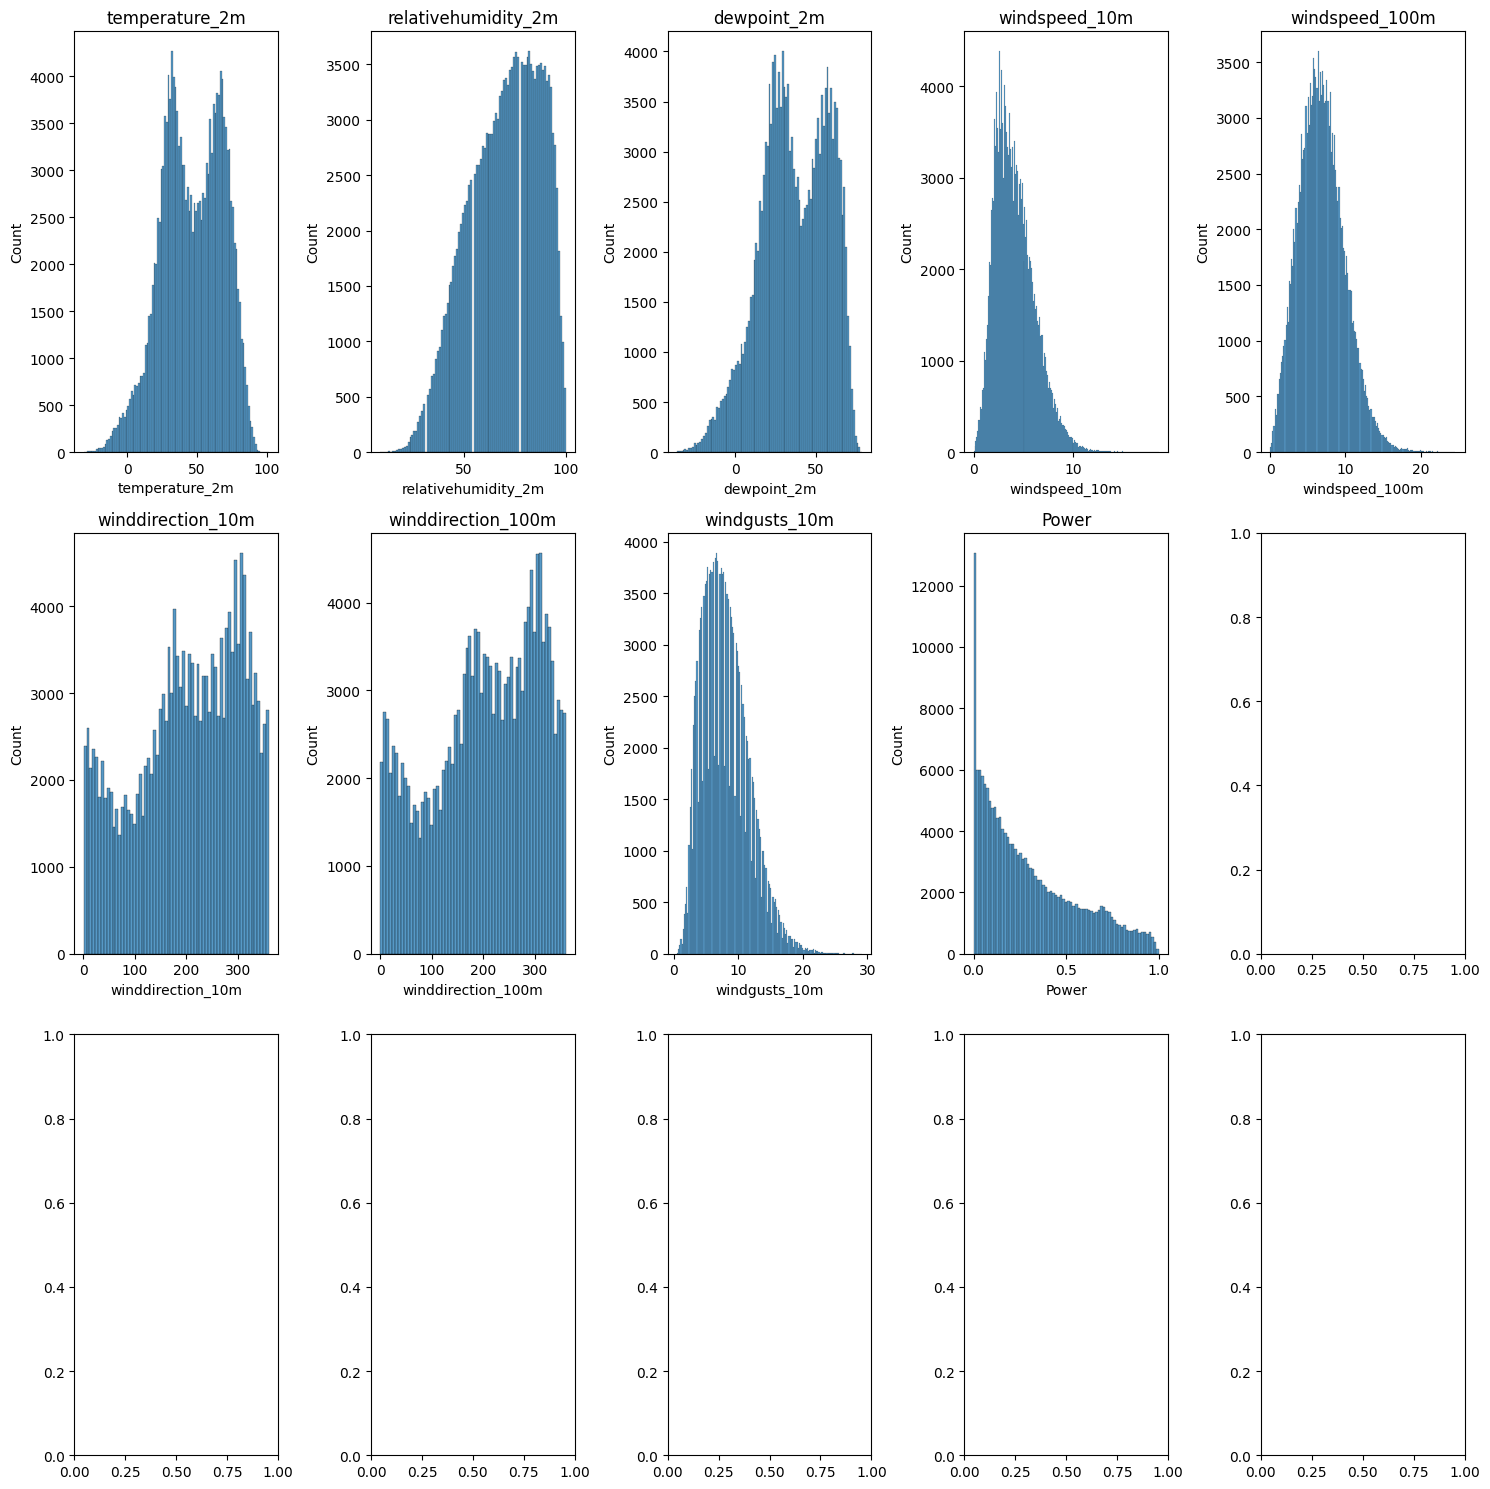

In [26]:
# Let's plot using subplots for the data distribution for each numerical column
fig, axes = plt.subplots(3, 5, figsize=(15, 15))
axes = axes.flatten()  # We have 2D array and for that we need indices, rows/cols, so converting into 1d array

for i, col in enumerate(numerical_columns):
    sns.histplot(merged_data[col], ax=axes[i])  # Use column name directly
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

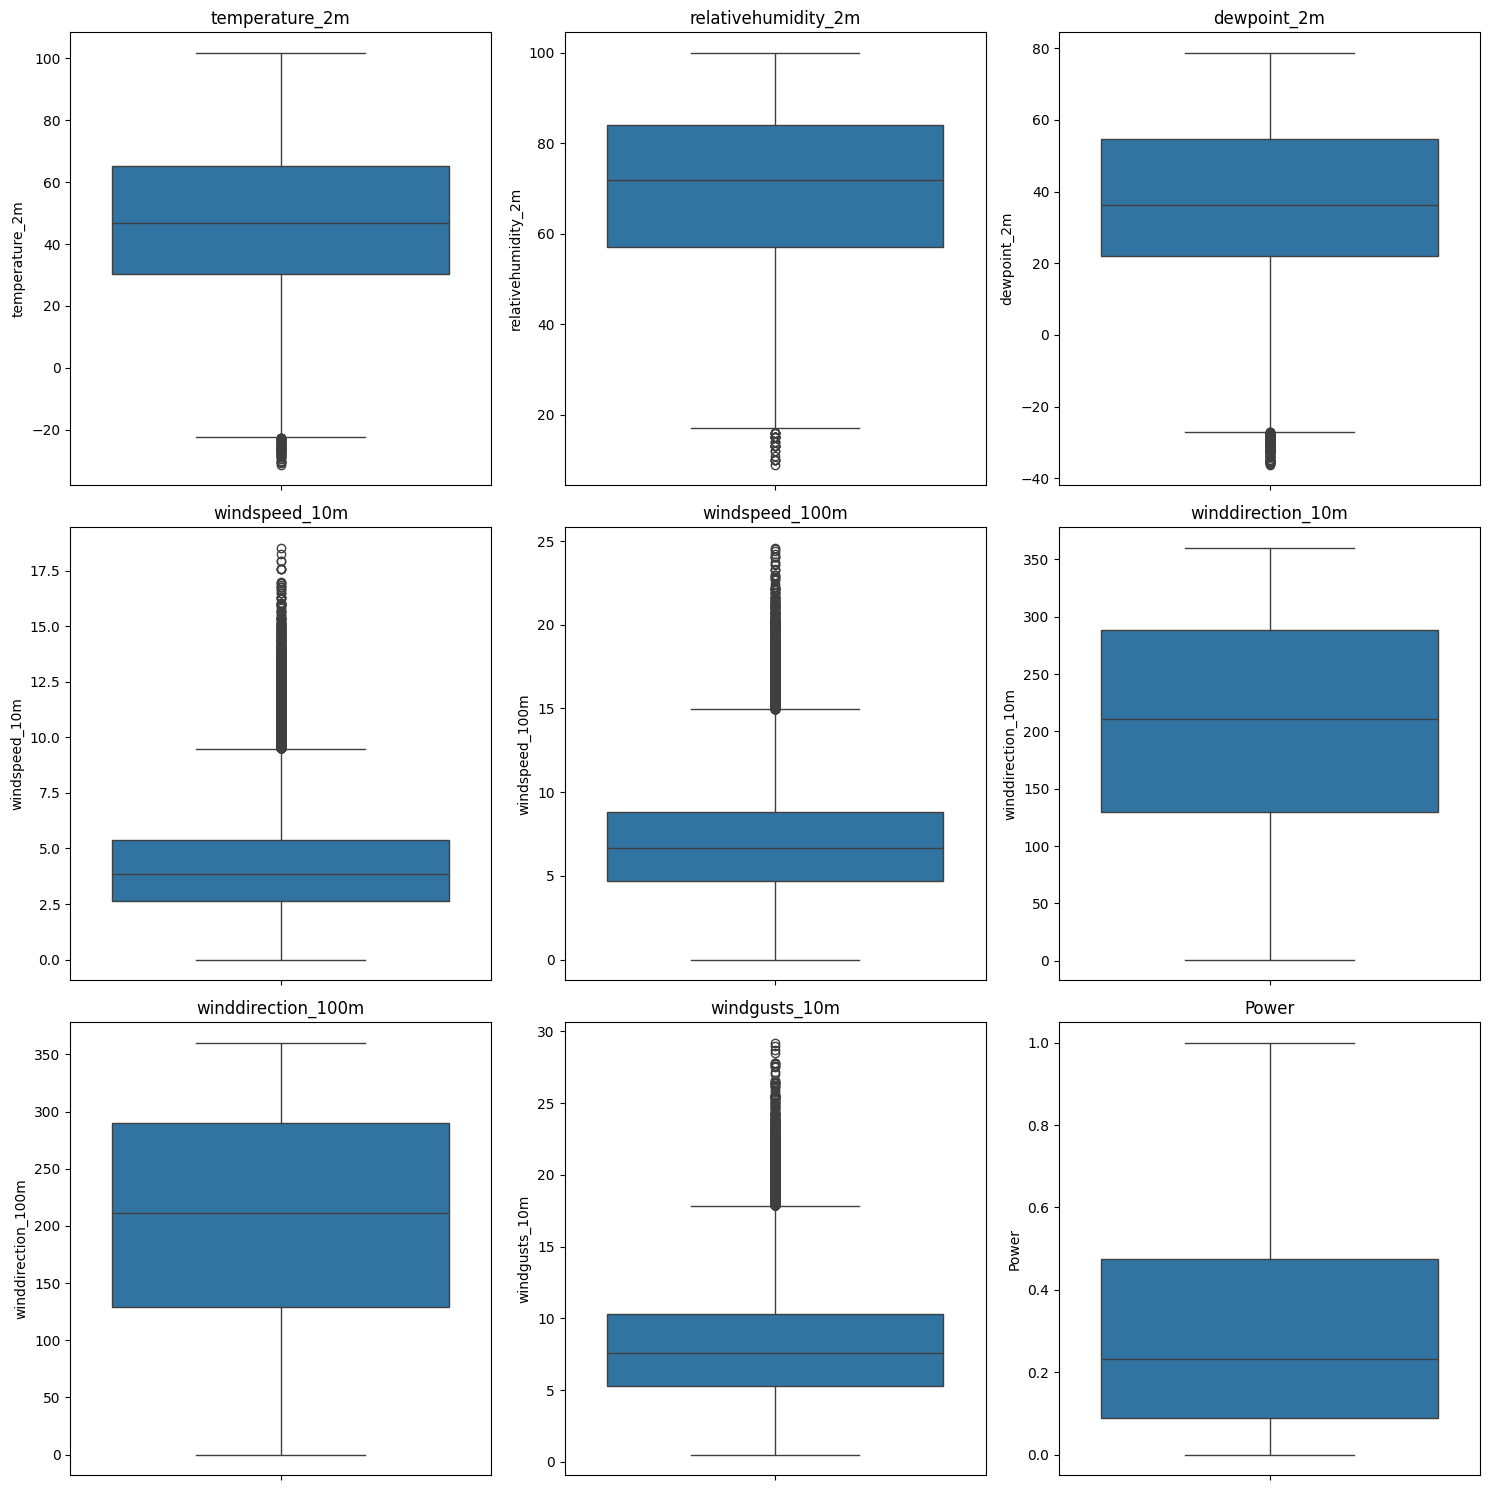

In [27]:
#let's create the box plot
fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.boxplot(merged_data[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


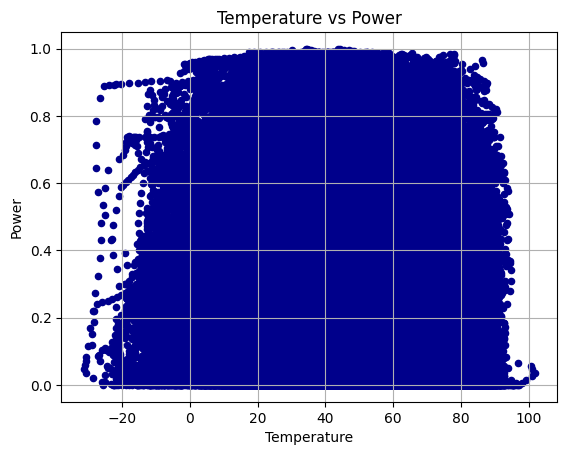

In [28]:
#let's  use scatter plot to see the relationnship between power & temp
merged_data.plot.scatter(x='temperature_2m', y='Power', c='DarkBlue')
plt.xlabel('Temperature')
plt.ylabel('Power')
plt.title('Temperature vs Power')
plt.grid(True)
plt.show()

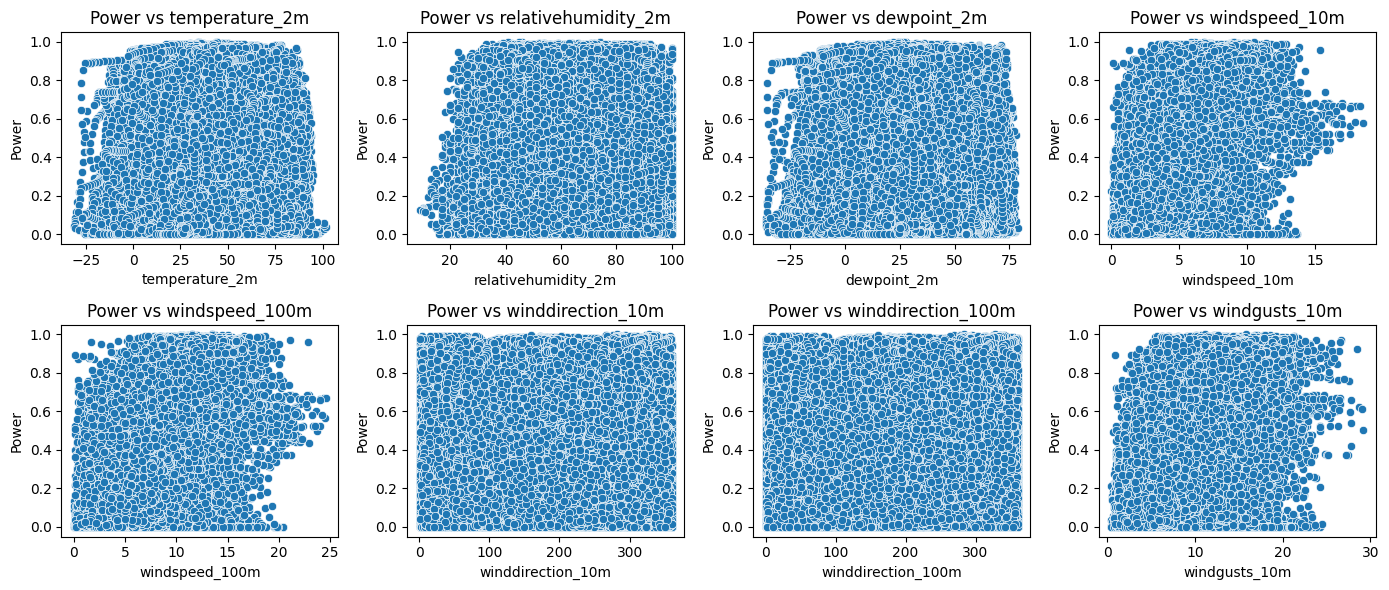

In [29]:
# Let's Create multiple plots to see the relation between different columns & power
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(numerical_columns.drop('Power')):
    sns.scatterplot(x=col, y='Power', data=merged_data, ax=axes[i])
    axes[i].set_title(f'Power vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Power')
plt.tight_layout()
plt.show()

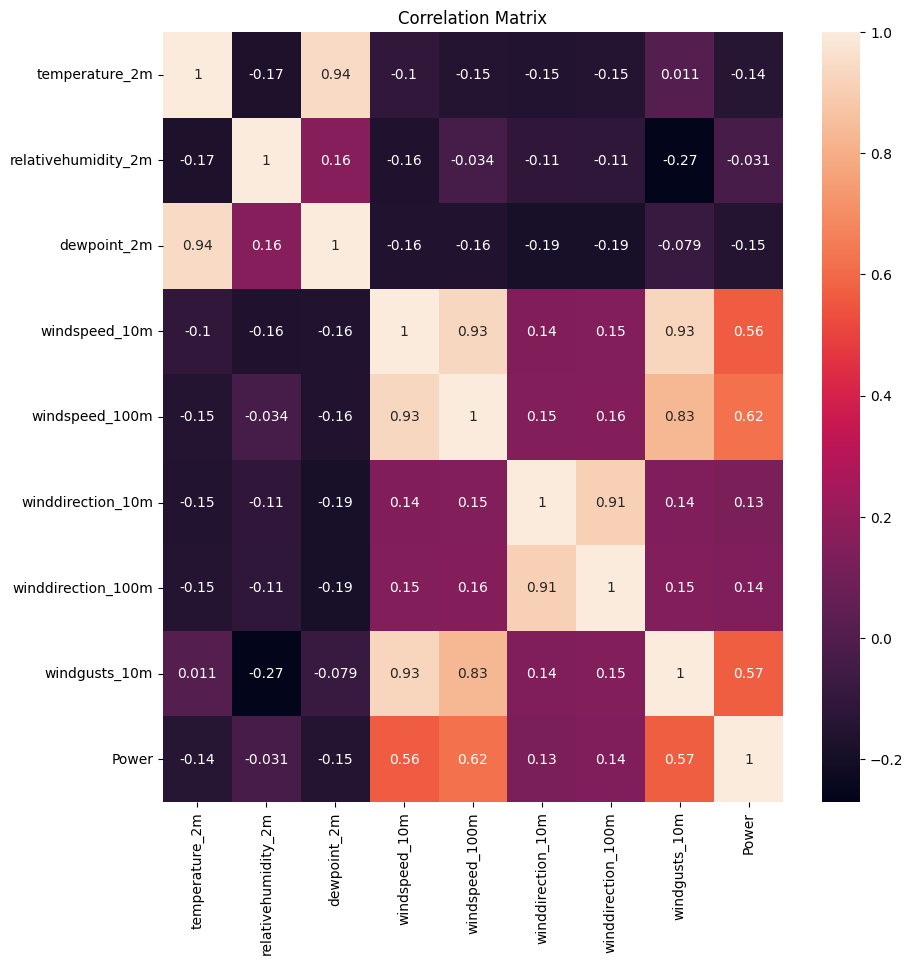

In [30]:
# Check the co-relation between the cols and Power
correlation = merged_data[numerical_columns].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, annot=True)
plt.title("Correlation Matrix")
plt.show()

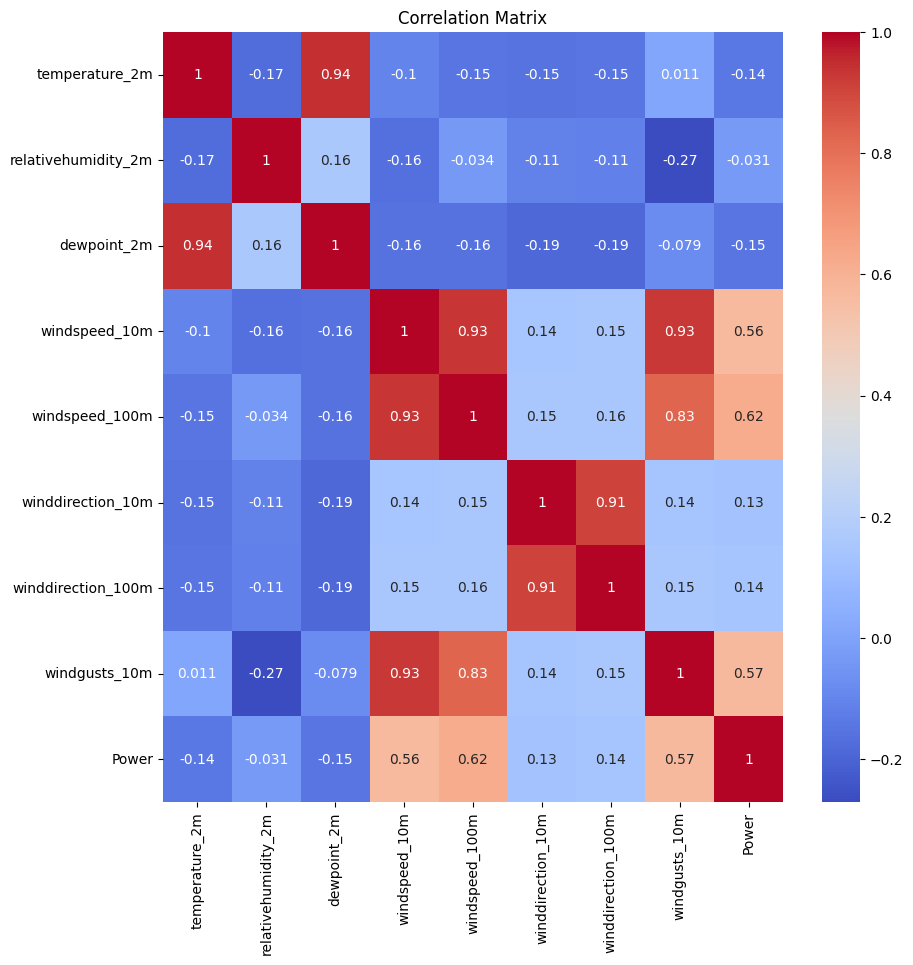

In [31]:
# Check the co-relation between the cols and Power
correlation = merged_data[numerical_columns].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [32]:
sns.histplot(merged_data[col], ax=axes[i], kde=True)

<Axes: title={'center': 'Power vs windgusts_10m'}, xlabel='windgusts_10m', ylabel='Power'>

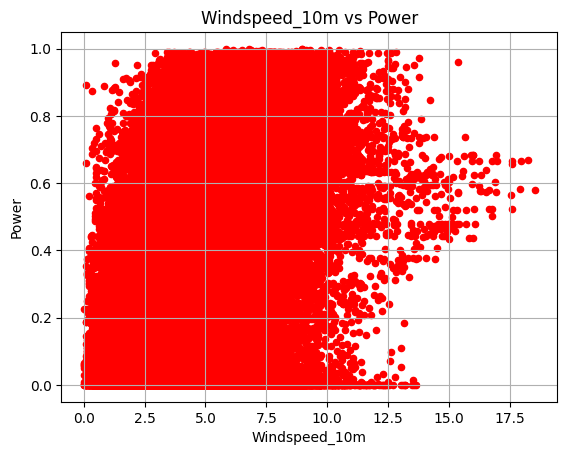

In [33]:
#let's  use scatter plot to see the relationnship between power & windspeed_10m
merged_data.plot.scatter(x='windspeed_10m', y='Power', c='Red')
plt.xlabel('Windspeed_10m')
plt.ylabel('Power')
plt.title('Windspeed_10m vs Power')
plt.grid(True)
plt.show()

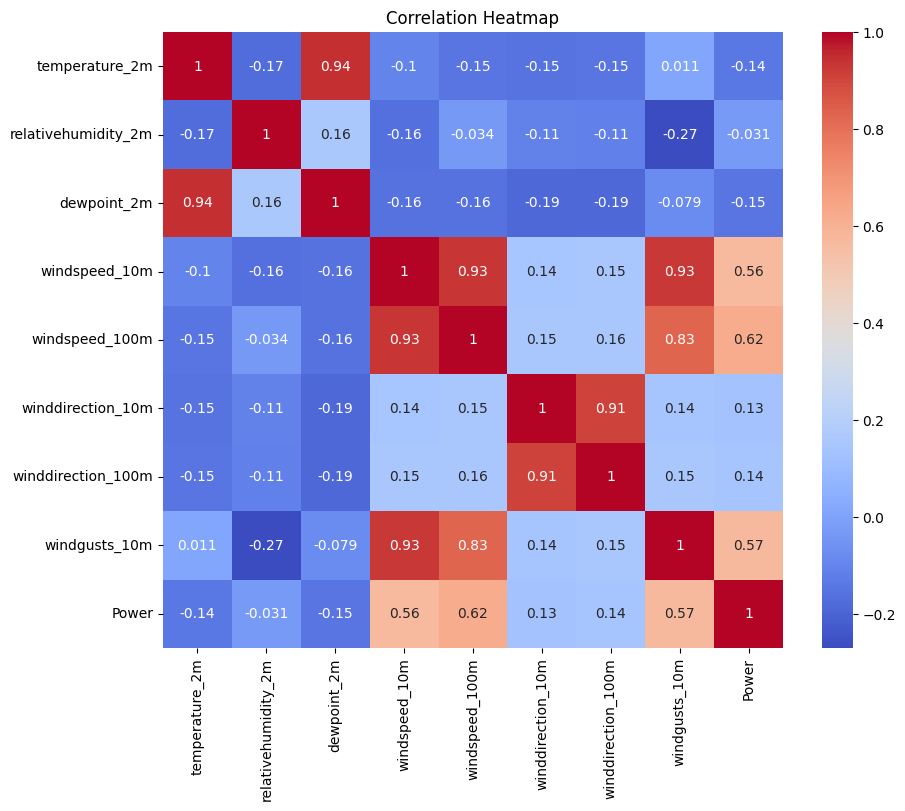

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(merged_data[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


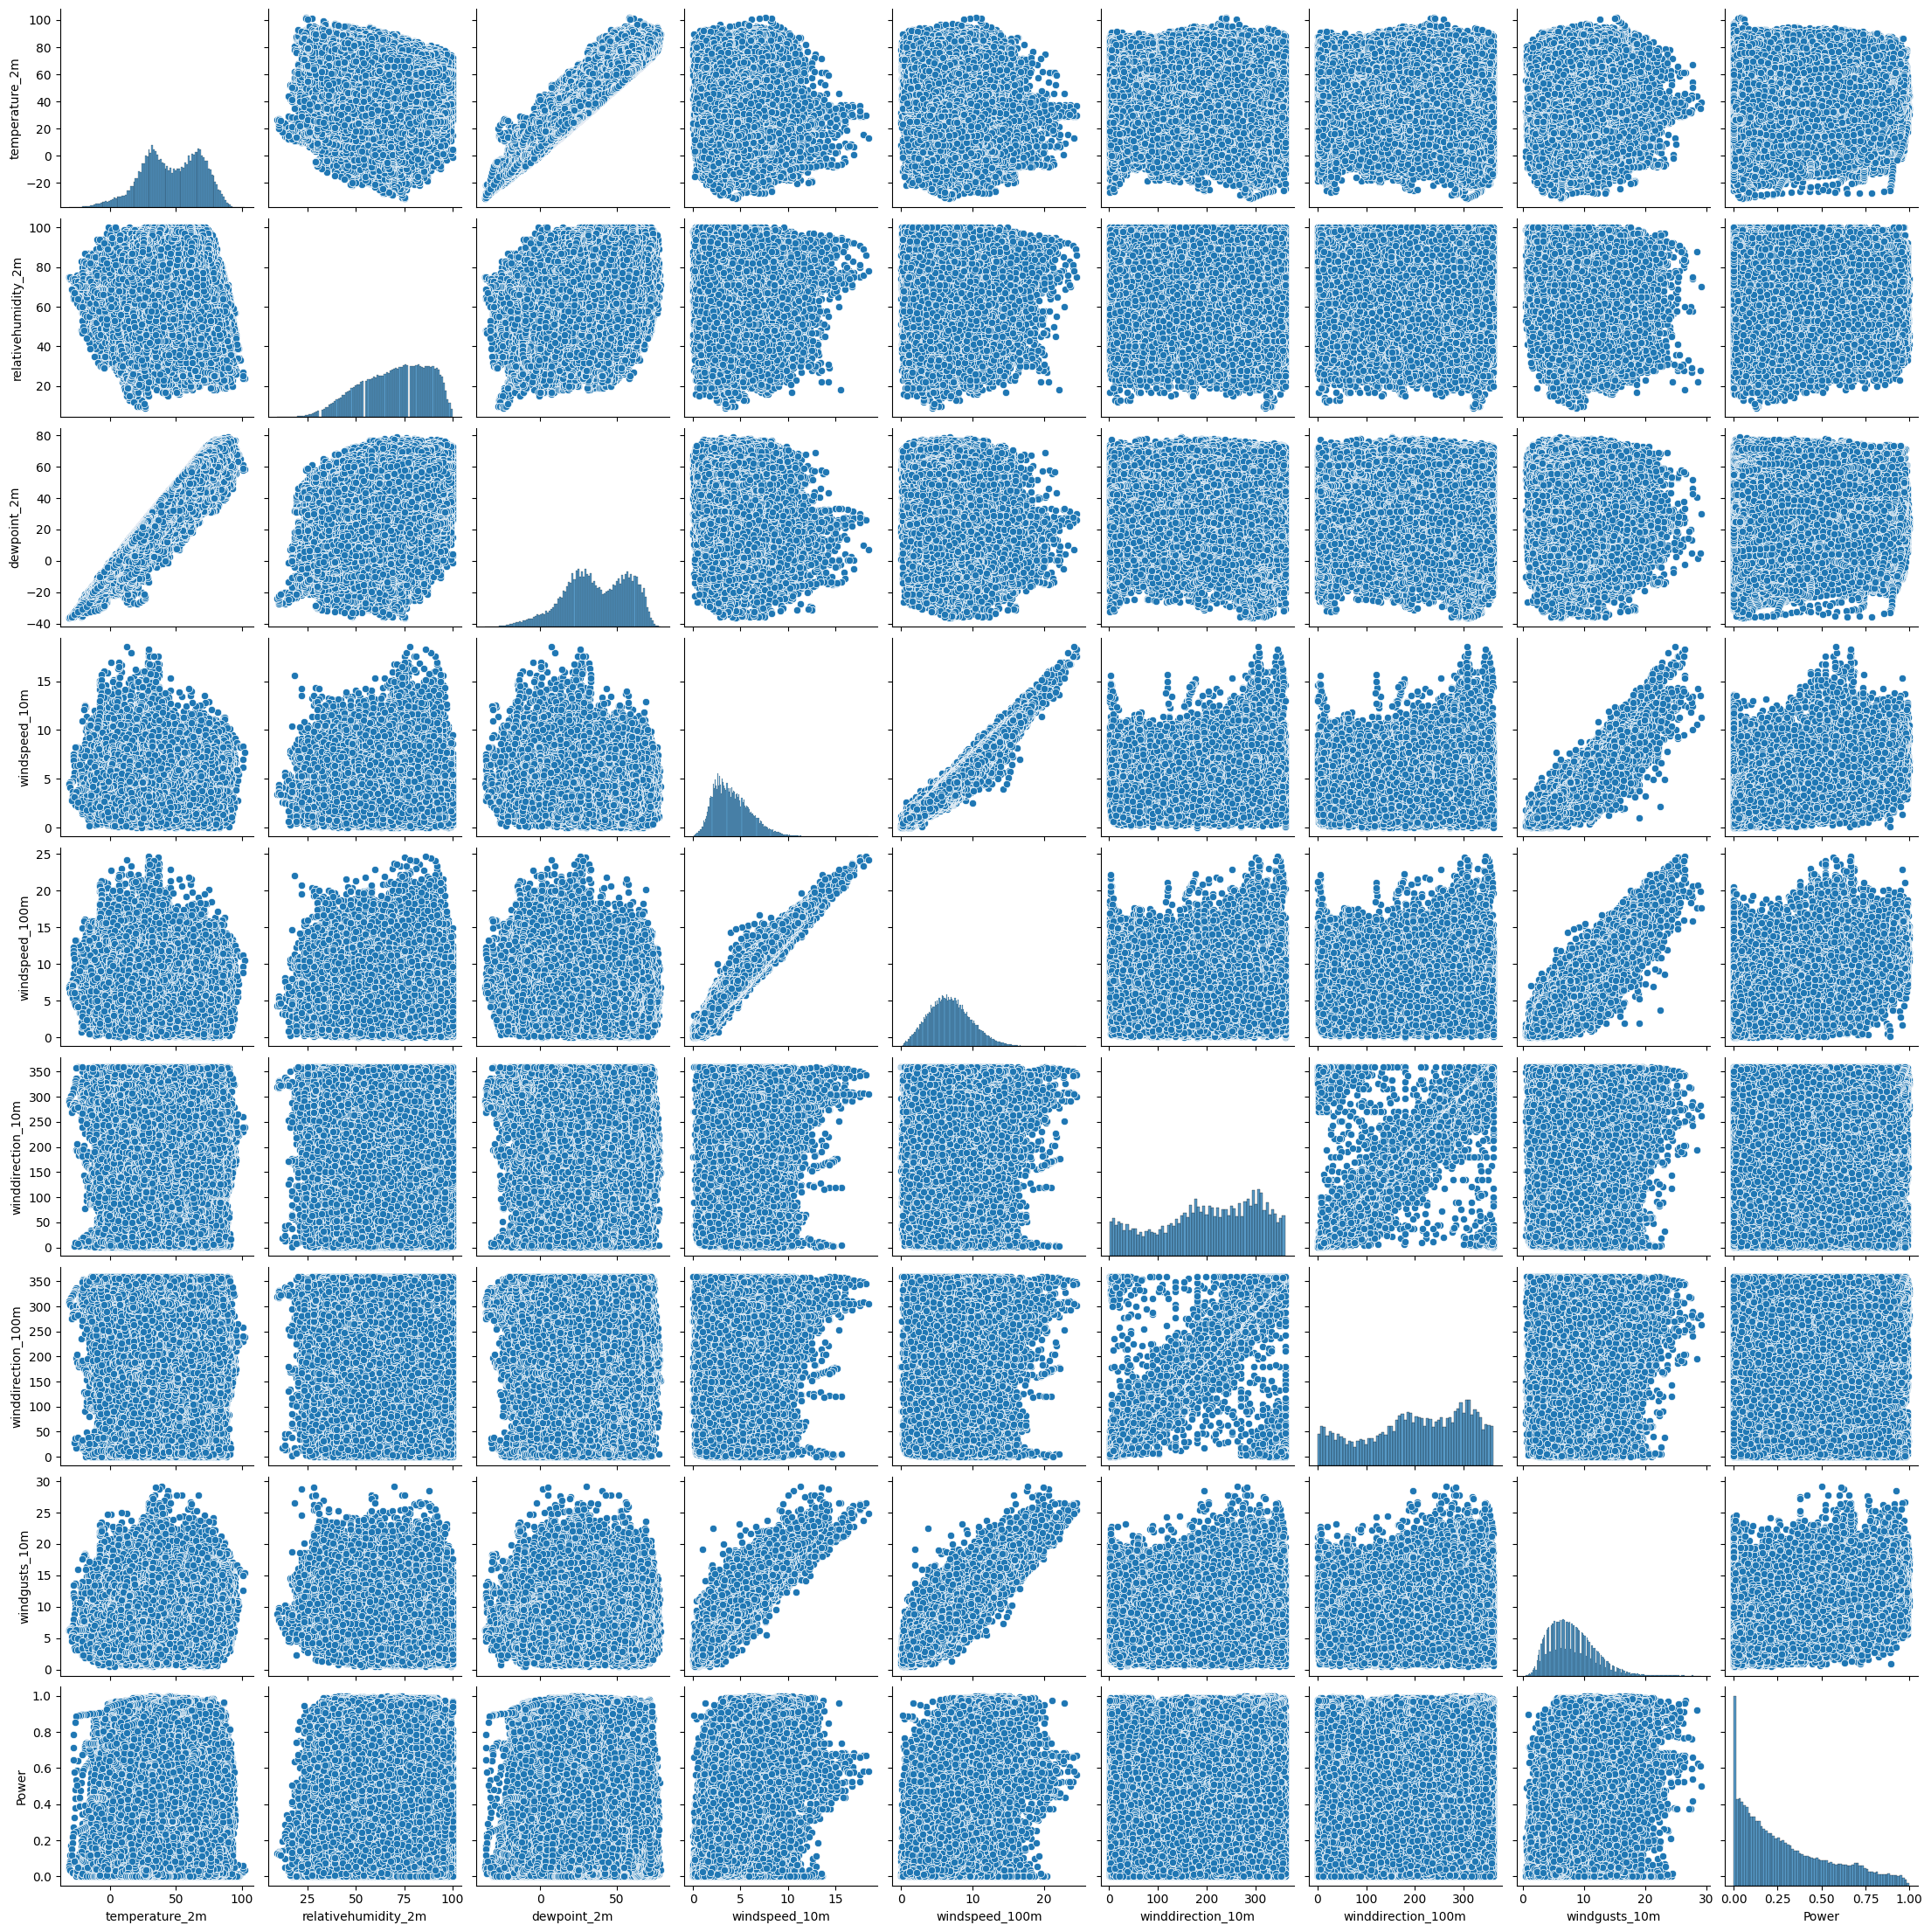

In [35]:
sns.pairplot(merged_data[numerical_columns])
plt.show()

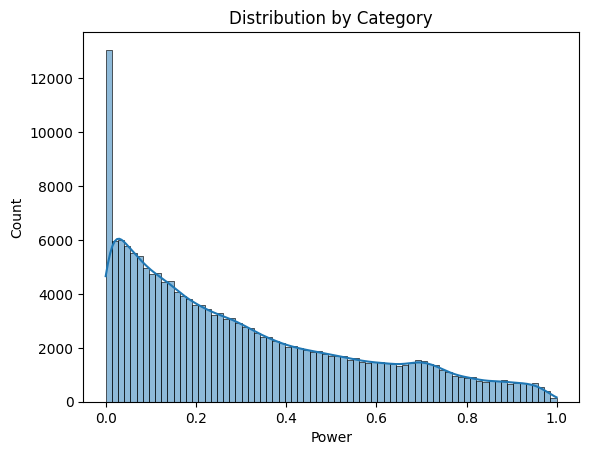

In [36]:
sns.histplot(data=merged_data, x='Power', kde=True)
plt.title('Distribution by Category')
plt.show()


In [37]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


<Axes: >

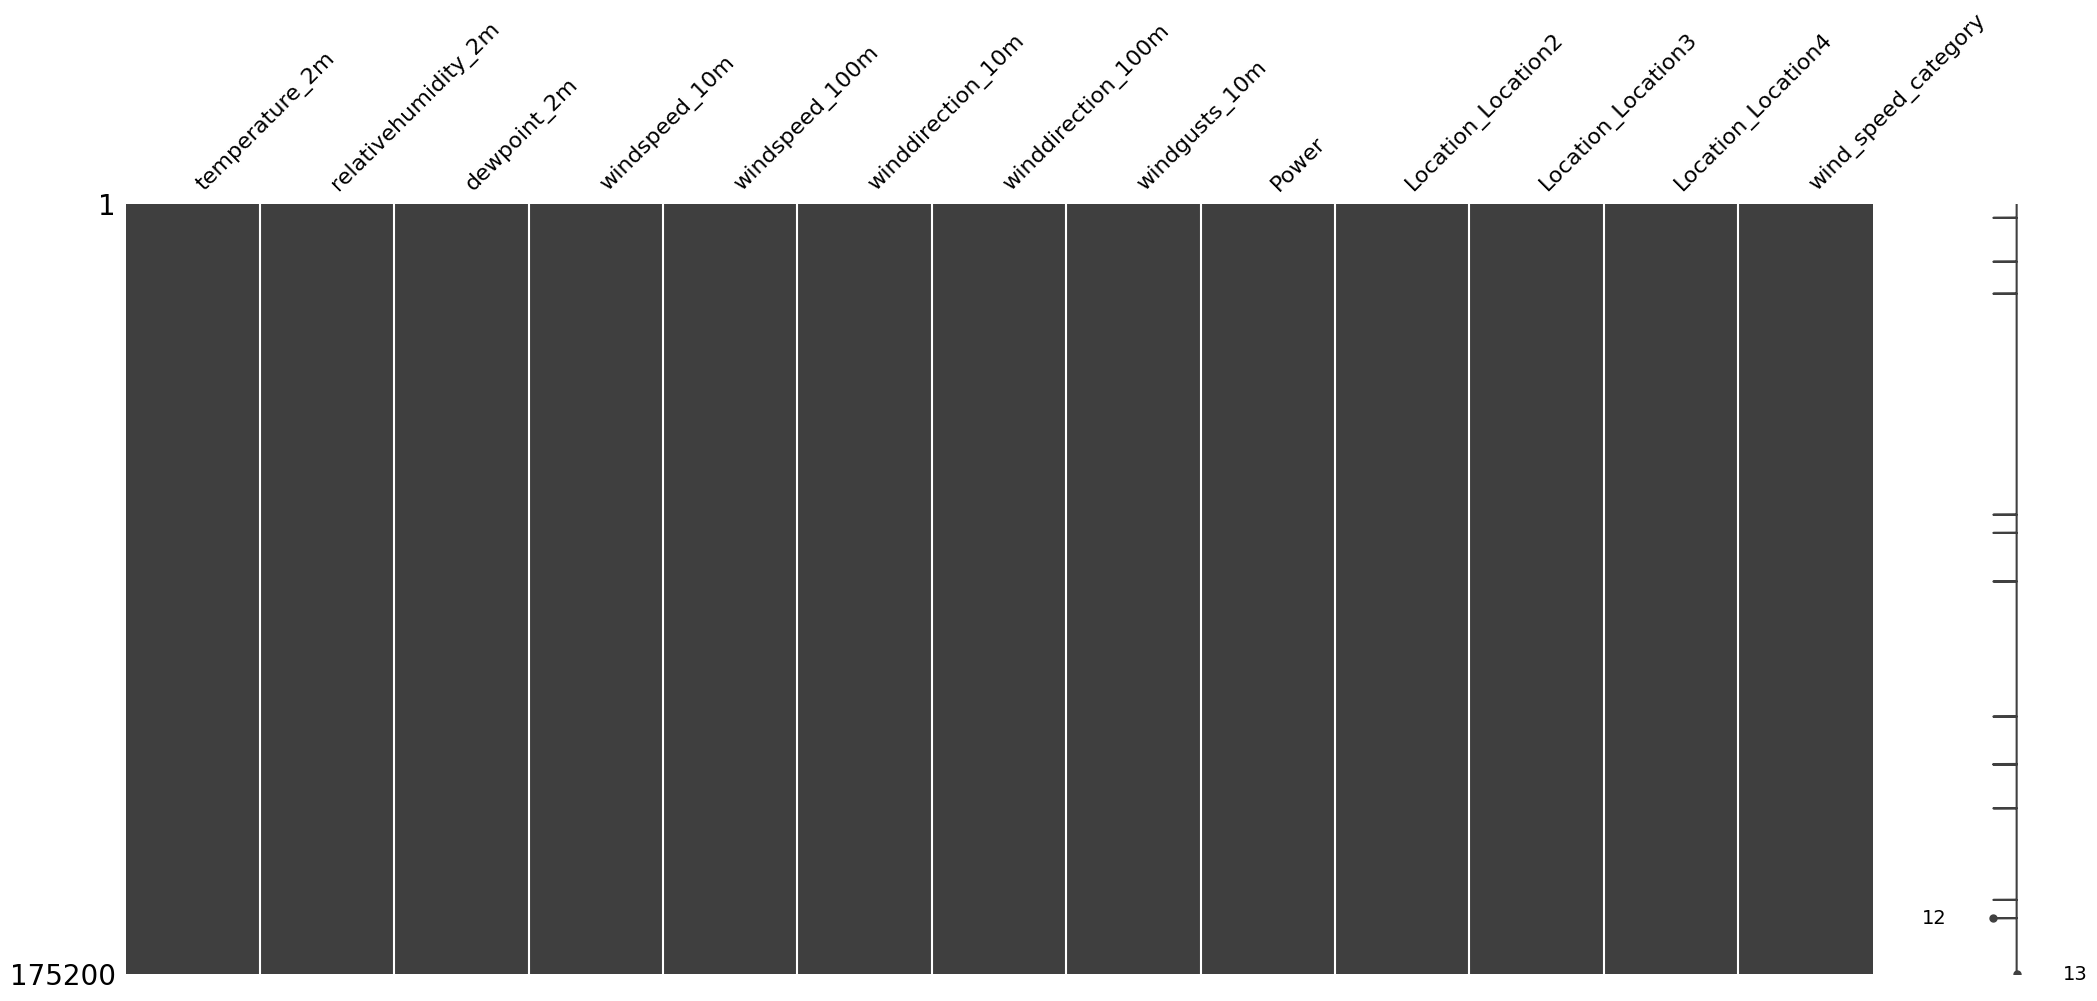

In [38]:
import missingno as msno
msno.matrix(merged_data)

In [39]:
print(merged_data.columns)

Index(['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m',
       'windspeed_100m', 'winddirection_10m', 'winddirection_100m',
       'windgusts_10m', 'Power', 'Location_Location2', 'Location_Location3',
       'Location_Location4', 'wind_speed_category'],
      dtype='object')


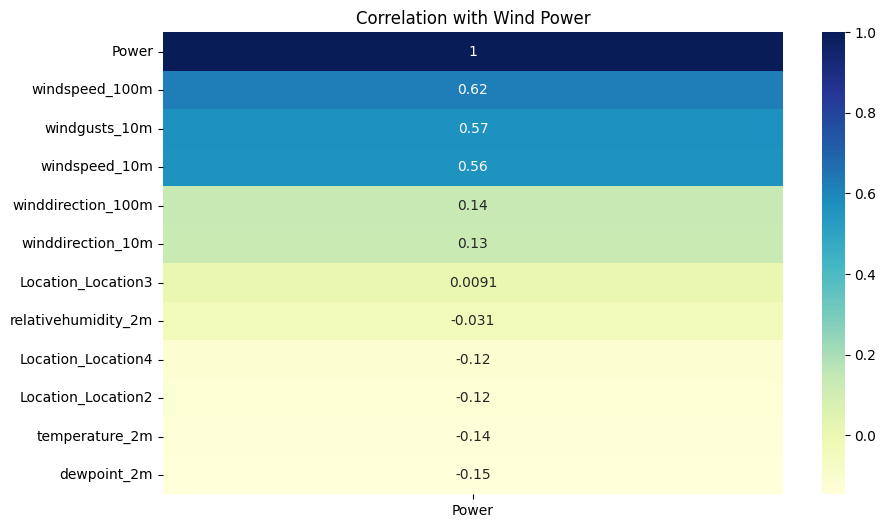

In [40]:
plt.figure(figsize=(10, 6))
sns.heatmap(merged_data.corr(numeric_only=True)[['Power']].sort_values('Power', ascending=False), annot=True, cmap='YlGnBu')
plt.title("Correlation with Wind Power")
plt.show()

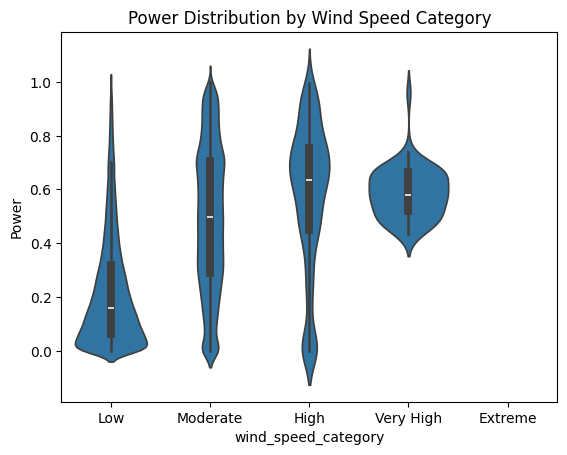

In [41]:
sns.violinplot(data=merged_data, x='wind_speed_category', y='Power')
plt.title('Power Distribution by Wind Speed Category')
plt.show()

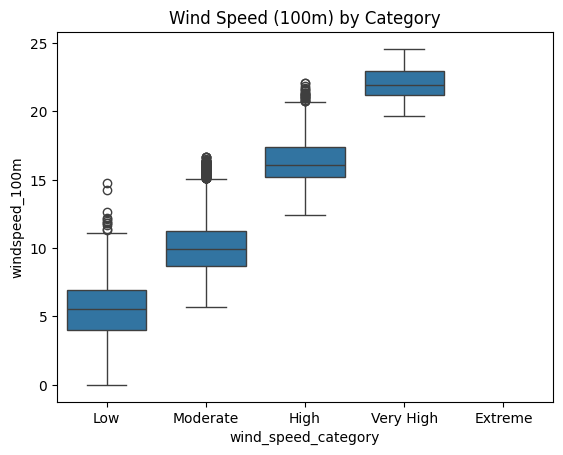

In [42]:
sns.boxplot(data=merged_data, x='wind_speed_category', y='windspeed_100m')
plt.title('Wind Speed (100m) by Category')
plt.show()

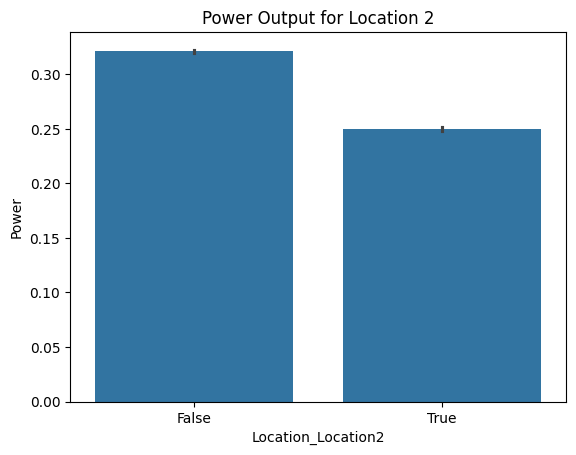

In [43]:
sns.barplot(data=merged_data, x='Location_Location2', y='Power')
plt.title("Power Output for Location 2")
plt.show()

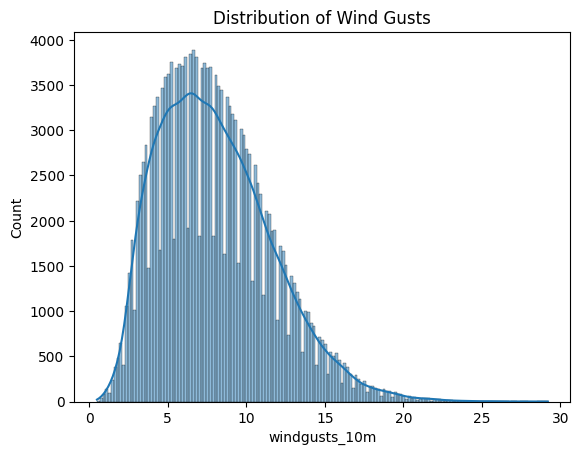

In [44]:
sns.histplot(merged_data['windgusts_10m'], kde=True)
plt.title("Distribution of Wind Gusts")
plt.show()

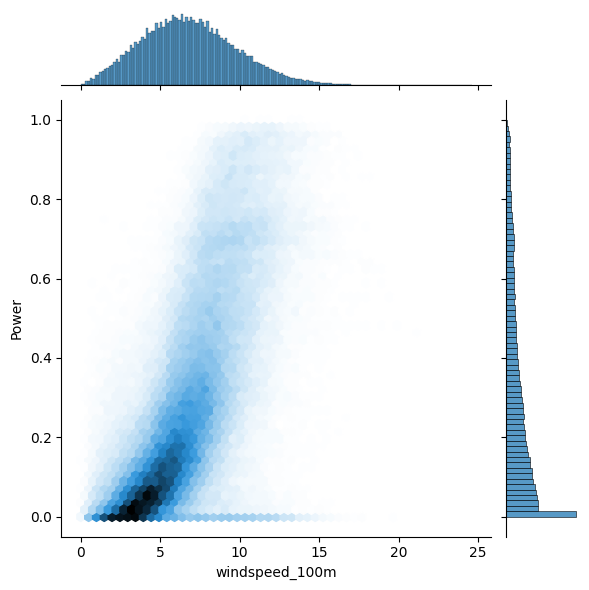

In [45]:
sns.jointplot(data=merged_data, x='windspeed_100m', y='Power', kind='hex')


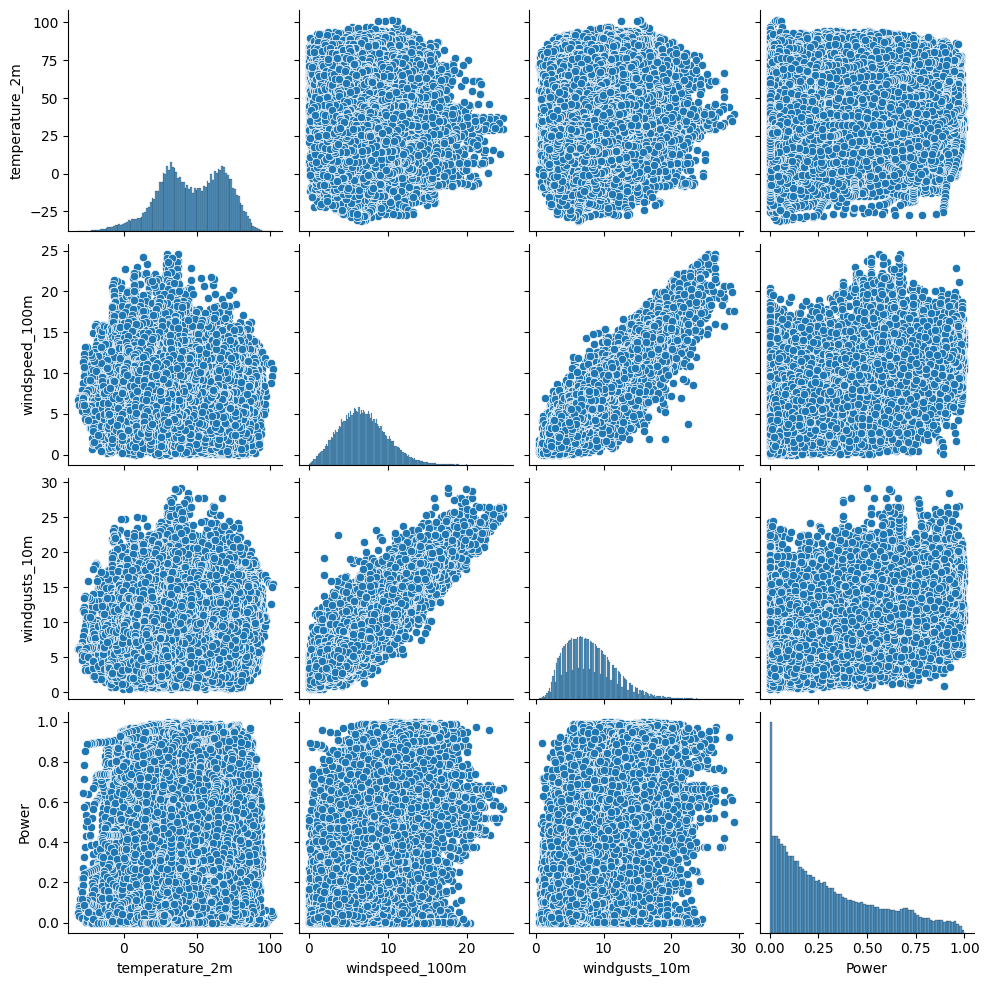

In [46]:
important_cols = ['temperature_2m', 'windspeed_100m', 'windgusts_10m', 'Power']
sns.pairplot(merged_data[important_cols])

# Week-3: Data modelling and evaluate

In [47]:
#Feature and target selection
X = merged_data.drop('Power',axis=1)# features
y = merged_data['Power']# target

In [48]:
# split the data into training and test sets -80% & 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
# Feature and target selection
X = merged_data.drop('Power', axis=1).select_dtypes(include=['int64', 'float64']) # features
y = merged_data['Power'] # target

# Split the data into training and test sets - 80% & 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
# train with linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# intialize teh model
model = LinearRegression()
#Train the model
model.fit(X_train, y_train)

LinearRegression()

In [51]:
# Make the predictions
y_pred = model.predict(X_test)

#Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R Squared Score: {r2}')

Mean Absolute Error: 0.14845993650342093
Mean Squared Error: 0.037181791353007185
R Squared Score: 0.443340367360887


In [52]:
# Train using Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

#Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

#Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [53]:
# Let's the make the prediction
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'RF MAE:{mae_rf}')
print(f'RF MSE:{mse_rf}')
print(f'RF R2:{r2_rf}')

RF MAE:0.12556599894406392
RF MSE:0.02807141656255899
RF R2:0.5797344919986007


In [54]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [55]:
# Train using XGBoost Regressor model
from xgboost import XGBRegressor
# Initialize the model
xgb_model = XGBRegressor()
#Train the model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
# Prediction
y_pred_xgb = xgb_model.predict(X_test)

#Evaluate model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'XGB MAE:{mae_xgb}')
print(f'XGB MSE:{mse_xgb}')
print(f'XGB R2:{r2_xgb}')



XGB MAE:0.12988336478857837
XGB MSE:0.03004632897408683
XGB R2:0.5501674921986677


In [58]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',  # Use MAE for evaluation
    cv=3,  # 3-fold cross-validation
    n_jobs=-1  # Use all available CPU cores
)

# Fit the GridSearchCV
grid_search.fit(X_train, y_train)

# Best parameters and best score
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best MAE: {-grid_search.best_score_}')

# Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f'Tuned Model Mean Absolute Error (MAE): {mae_tuned}')
print(f'Tuned Model Mean Squared Error (MSE): {mse_tuned}')
print(f'Tuned Model R^2 Score: {r2_tuned}')

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best MAE: 0.12856371330356983
Tuned Model Mean Absolute Error (MAE): 0.12772977522868403
Tuned Model Mean Squared Error (MSE): 0.029076909116507742
Tuned Model R^2 Score: 0.5646809645773834


In [59]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
merged_data[numerical_columns] = imputer.fit_transform(merged_data[numerical_columns])


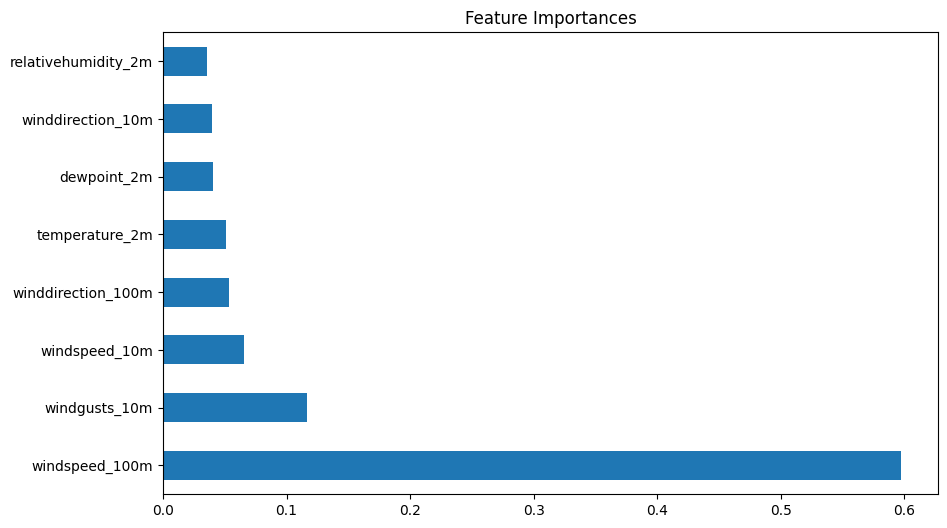

In [61]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='barh', figsize=(10, 6), title="Feature Importances")
plt.show()


In [62]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [63]:
import joblib
joblib.dump(best_model, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']